# Riconoscimento dell'attività umana da smartphone
## Progetto di Apprendimento Automatico e Apprendimento Profondo

**Studente:** Leonardo Angelini — **Matricola:** 0322500161
**Docente:** Prof.ssa Noemi Scarpato
**Dataset:** [Human Activity Recognition Using Smartphones](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones) (UCI, id 240)

### Obiettivo
Classificare l'attività svolta da una persona (camminare, salire le scale, scendere le scale, stare seduta, stare in piedi, stare sdraiata) a partire dai segnali dell'accelerometro e del giroscopio di uno smartphone indossato in vita.

### Struttura del notebook (segue i punti della traccia)
1. Caricamento ed esplorazione del dataset
2. Suddivisione in training, validation e test set
3. **Punto 1** — Analisi delle feature con PCA
4. **Punto 2** — Tre algoritmi di classificazione (Logistic Regression, SVM, Random Forest)
5. **Punti 3 e 4** — Metriche (precision, recall, F-measure, accuracy, ROC AUC), matrici di confusione e curve ROC
6. **Punto 5a** — Approccio di deep learning (rete MLP in PyTorch) sulla stessa suddivisione dei dati
7. Confronto finale e conclusioni

## 0. Librerie e configurazione

In [1]:
import os
import random
import warnings
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, auc, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_theme(style="whitegrid")
OUT = Path("outputs")
OUT.mkdir(exist_ok=True)


def salva(nome):
    # Salva la figura corrente in outputs/ (usata poi nella relazione)
    plt.savefig(OUT / f"{nome}.png", dpi=150, bbox_inches="tight")

## 1. Caricamento ed esplorazione del dataset

Il dataset non è importabile con `ucimlrepo`, quindi viene scaricato lo zip ufficiale da UCI (circa 60 MB, solo la prima volta).

Ogni riga è una finestra di 2,56 secondi di segnale (128 campioni a 50 Hz) descritta da **561 feature** già calcolate nel dominio del tempo e della frequenza (medie, deviazioni standard, energia, entropia, coefficienti spettrali…). Le registrazioni provengono da **30 volontari** tra i 19 e i 48 anni.

In [2]:
DATA_DIR = Path("data")
HAR_DIR = DATA_DIR / "UCI HAR Dataset"
URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"

if not HAR_DIR.exists():
    DATA_DIR.mkdir(exist_ok=True)
    zip_esterno = DATA_DIR / "har.zip"
    urllib.request.urlretrieve(URL, zip_esterno)
    with zipfile.ZipFile(zip_esterno) as z:
        z.extractall(DATA_DIR)
    # Lo zip UCI contiene a sua volta lo zip con i dati
    with zipfile.ZipFile(DATA_DIR / "UCI HAR Dataset.zip") as z:
        z.extractall(DATA_DIR)

# Nomi delle feature: 42 nomi sono duplicati nel file originale, li rendiamo univoci
nomi = pd.read_csv(HAR_DIR / "features.txt", sep=r"\s+", header=None, names=["idx", "nome"])["nome"]
conteggio = nomi.groupby(nomi).cumcount()
feature_names = np.where(conteggio > 0, nomi + "_" + conteggio.astype(str), nomi)

etichette = pd.read_csv(HAR_DIR / "activity_labels.txt", sep=r"\s+", header=None, names=["id", "attivita"])
CLASSI = etichette["attivita"].tolist()


def carica(parte):
    X = pd.read_csv(HAR_DIR / parte / f"X_{parte}.txt", sep=r"\s+", header=None, names=feature_names)
    y = pd.read_csv(HAR_DIR / parte / f"y_{parte}.txt", header=None)[0] - 1          # classi 0..5
    soggetti = pd.read_csv(HAR_DIR / parte / f"subject_{parte}.txt", header=None)[0]
    return X, y, soggetti


X_train_full, y_train_full, sogg_train_full = carica("train")
X_test, y_test, sogg_test = carica("test")

print("Train ufficiale:", X_train_full.shape, "- volontari:", sorted(sogg_train_full.unique().tolist()))
print("Test ufficiale: ", X_test.shape, "- volontari:", sorted(sogg_test.unique().tolist()))
print("Classi:", CLASSI)

Train ufficiale: (7352, 561) - volontari: [1, 3, 5, 6, 7, 8, 11, 14, 15, 16, 17, 19, 21, 22, 23, 25, 26, 27, 28, 29, 30]
Test ufficiale:  (2947, 561) - volontari: [2, 4, 9, 10, 12, 13, 18, 20, 24]
Classi: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


In [3]:
X_tutto = pd.concat([X_train_full, X_test])
y_tutto = pd.concat([y_train_full, y_test])

print("Valori mancanti:", X_tutto.isna().sum().sum())
print("Righe duplicate:", X_tutto.duplicated().sum())
print(f"Intervallo dei valori: [{X_tutto.values.min():.2f}, {X_tutto.values.max():.2f}]")
X_tutto.iloc[:, :8].describe().round(3)

Valori mancanti: 0


Righe duplicate: 0
Intervallo dei valori: [-1.00, 1.00]


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y
count,10299.000,10299.000,10299.000,10299.000,10299.000,10299.000,10299.000,10299.000
mean,0.274,-0.018,-0.109,-0.608,-0.510,-0.613,-0.634,-0.526
std,0.068,0.037,0.053,0.439,0.500,0.404,0.413,0.484
min,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000
25%,0.263,-0.025,-0.121,-0.992,-0.977,-0.979,-0.993,-0.977
50%,0.277,-0.017,-0.109,-0.943,-0.835,-0.851,-0.948,-0.844
75%,0.288,-0.011,-0.098,-0.250,-0.057,-0.279,-0.302,-0.087
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


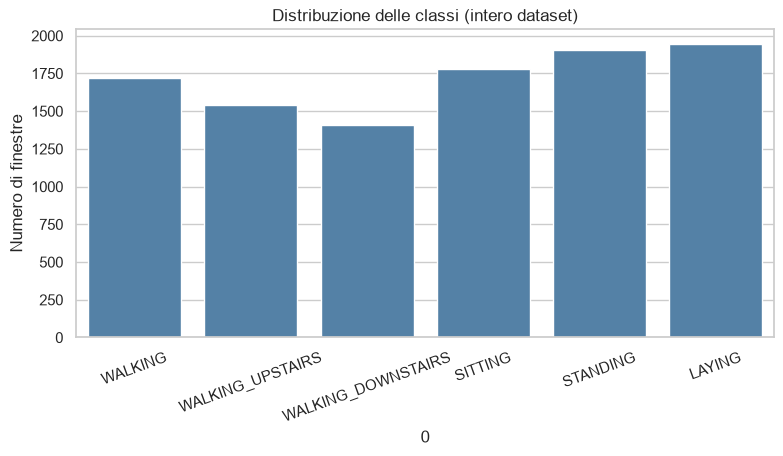

0
WALKING               16.7
WALKING_UPSTAIRS      15.0
WALKING_DOWNSTAIRS    13.7
SITTING               17.3
STANDING              18.5
LAYING                18.9
Name: %, dtype: float64

In [4]:
distribuzione = y_tutto.map(dict(enumerate(CLASSI))).value_counts().reindex(CLASSI)

plt.figure(figsize=(9, 4))
sns.barplot(x=distribuzione.index, y=distribuzione.values, color="steelblue")
plt.title("Distribuzione delle classi (intero dataset)")
plt.ylabel("Numero di finestre")
plt.xticks(rotation=20)
salva("01_distribuzione_classi")
plt.show()

(distribuzione / distribuzione.sum() * 100).round(1).rename("%")

**Osservazioni.** Il dataset non ha valori mancanti né duplicati e le feature sono già normalizzate nell'intervallo [-1, 1]. Le sei classi sono **abbastanza bilanciate** (dal 13% al 19% circa), quindi l'accuracy resta una metrica significativa; riportiamo comunque anche le metriche *macro* (media non pesata sulle classi), che trattano tutte le attività allo stesso modo.

## 2. Suddivisione in training, validation e test set

La lezione 6 raccomanda di dividere i dati in tre insiemi con proporzioni indicative 70/20/10, in modo stratificato e riproducibile (`random_state`). Il dataset HAR, però, ha una particolarità: **le finestre dello stesso volontario si somigliano molto**. Se le stesse persone finissero sia nel training sia nel test, il modello verrebbe valutato su persone che ha già "visto" e le metriche sarebbero troppo ottimistiche.

Per questo:
- come **test set** usiamo la partizione ufficiale del benchmark (9 volontari mai visti in addestramento). È il caso dei "benchmark pubblici dove le partizioni sono predefinite per consentire confronti obiettivi tra algoritmi" citato nella lezione;
- il **validation set** viene ricavato dal training ufficiale tenendo da parte circa il 20% dei volontari (`GroupShuffleSplit`, `random_state=42`), così anche la scelta degli iperparametri avviene su persone nuove.

La divisione è per volontario e non per singola riga: la stratificazione per classe è comunque garantita di fatto, perché ogni volontario ha svolto tutte e sei le attività (lo verifichiamo sotto).

**Questa stessa divisione viene usata per tutti i modelli, compresa la rete neurale.**

In [5]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train, idx_val = next(gss.split(X_train_full, y_train_full, groups=sogg_train_full))

X_train, y_train = X_train_full.iloc[idx_train], y_train_full.iloc[idx_train]
X_val, y_val = X_train_full.iloc[idx_val], y_train_full.iloc[idx_val]

totale = len(X_train_full) + len(X_test)
for nome, X_, s_ in [("Training", X_train, sogg_train_full.iloc[idx_train]),
                     ("Validation", X_val, sogg_train_full.iloc[idx_val]),
                     ("Test", X_test, sogg_test)]:
    print(f"{nome:<11} {len(X_):>5} righe ({len(X_) / totale:5.1%}) - {s_.nunique()} volontari: {sorted(s_.unique().tolist())}")

# Verifica: la distribuzione delle classi è simile nei tre insiemi
pd.DataFrame({
    "train %": y_train.value_counts(normalize=True).sort_index() * 100,
    "val %": y_val.value_counts(normalize=True).sort_index() * 100,
    "test %": y_test.value_counts(normalize=True).sort_index() * 100,
}).set_axis(CLASSI).round(1)

Training     5551 righe (53.9%) - 16 volontari: [5, 6, 7, 8, 11, 14, 16, 17, 19, 21, 22, 23, 26, 28, 29, 30]
Validation   1801 righe (17.5%) - 5 volontari: [1, 3, 15, 25, 27]
Test         2947 righe (28.6%) - 9 volontari: [2, 4, 9, 10, 12, 13, 18, 20, 24]


,train %,val %,test %
WALKING,16.0,18.8,16.8
WALKING_UPSTAIRS,14.4,15.3,16.0
WALKING_DOWNSTAIRS,13.4,13.4,14.3
SITTING,17.9,16.3,16.7
STANDING,19.0,17.8,18.1
LAYING,19.4,18.4,18.2


**Standardizzazione.** Lo `StandardScaler` viene addestrato **solo sul training set** e poi applicato a validation e test: in questo modo nessuna informazione dei dati di valutazione entra nell'addestramento (*data leakage*).

In [6]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

y_train, y_val, y_test = y_train.to_numpy(), y_val.to_numpy(), y_test.to_numpy()
print(X_train_s.shape, X_val_s.shape, X_test_s.shape)

(5551, 561) (1801, 561) (2947, 561)


## 3. Punto 1 — Analisi delle feature con PCA

La PCA trasforma le 561 feature (molte delle quali fortemente correlate, ad esempio media e mediana dello stesso segnale) in componenti principali non correlate, ordinate per varianza spiegata. Come nella lezione 24:
- i dati vengono centrati con lo `StandardScaler` (già fatto sopra);
- si calcola l'**Explained Variance Ratio** individuale e cumulativa per decidere quante componenti servono a mantenere il 90–95% della varianza;
- si visualizzano i dati sulle prime due (e tre) componenti.

La PCA viene stimata solo sul training set.

PC1 spiega il 51.1% della varianza, PC2 il 6.3%, PC3 il 2.8%
Componenti per il 90% della varianza: 61
Componenti per il 95% della varianza: 100
Componenti per il 99% della varianza: 176 (su 561 feature)


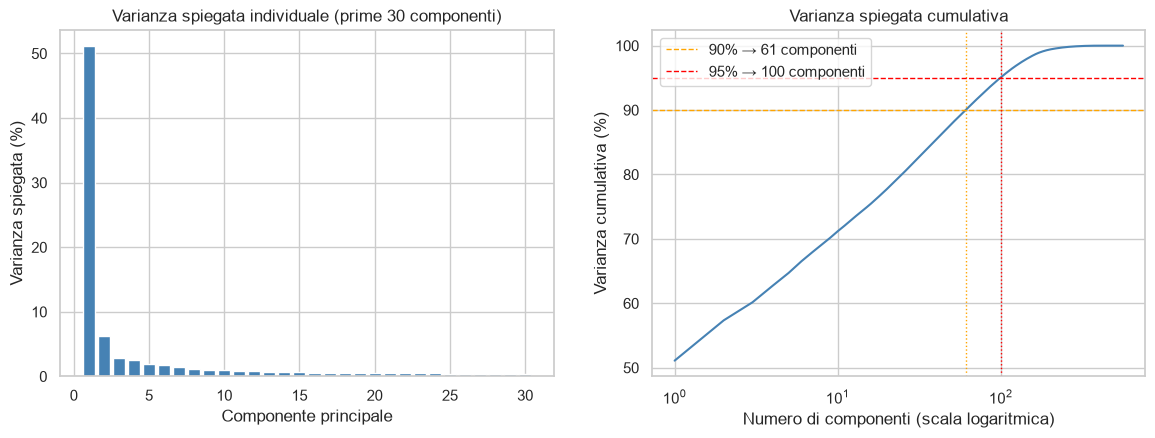

In [7]:
pca_full = PCA(random_state=SEED).fit(X_train_s)
evr = pca_full.explained_variance_ratio_
cumulata = np.cumsum(evr)

n90 = int(np.argmax(cumulata >= 0.90)) + 1
n95 = int(np.argmax(cumulata >= 0.95)) + 1
n99 = int(np.argmax(cumulata >= 0.99)) + 1
print(f"PC1 spiega il {evr[0]:.1%} della varianza, PC2 il {evr[1]:.1%}, PC3 il {evr[2]:.1%}")
print(f"Componenti per il 90% della varianza: {n90}")
print(f"Componenti per il 95% della varianza: {n95}")
print(f"Componenti per il 99% della varianza: {n99} (su 561 feature)")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].bar(range(1, 31), evr[:30] * 100, color="steelblue")
ax[0].set_title("Varianza spiegata individuale (prime 30 componenti)")
ax[0].set_xlabel("Componente principale")
ax[0].set_ylabel("Varianza spiegata (%)")

ax[1].plot(range(1, len(cumulata) + 1), cumulata * 100, color="steelblue")
for soglia, n, colore in [(90, n90, "orange"), (95, n95, "red")]:
    ax[1].axhline(soglia, ls="--", color=colore, lw=1, label=f"{soglia}% → {n} componenti")
    ax[1].axvline(n, ls=":", color=colore, lw=1)
ax[1].set_xscale("log")
ax[1].set_title("Varianza spiegata cumulativa")
ax[1].set_xlabel("Numero di componenti (scala logaritmica)")
ax[1].set_ylabel("Varianza cumulativa (%)")
ax[1].legend()
salva("02_pca_varianza_spiegata")
plt.show()

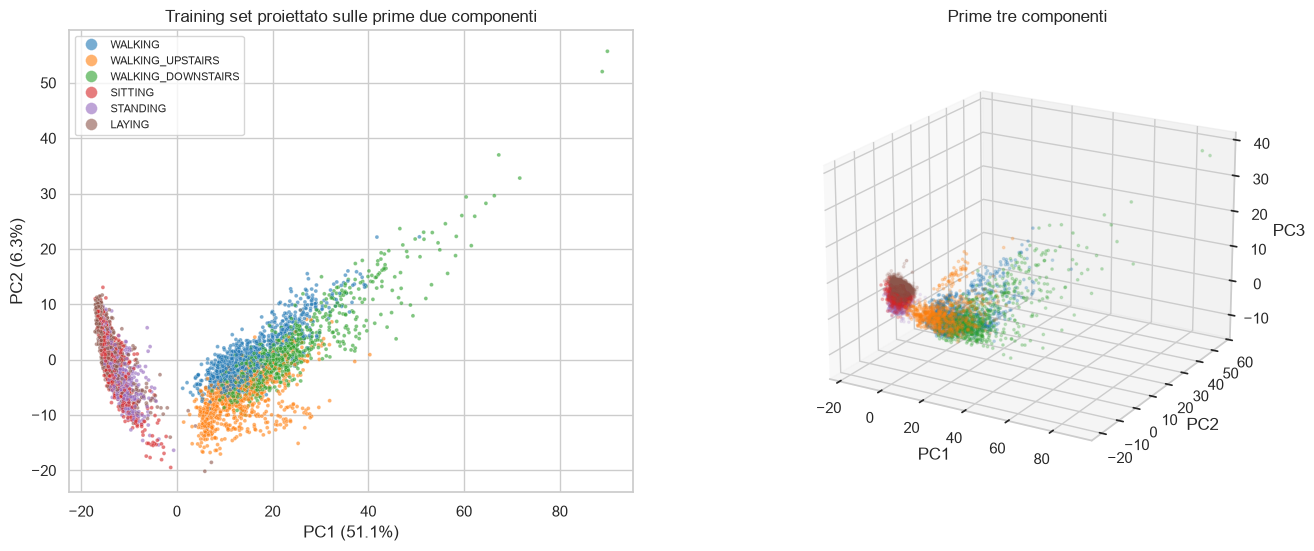

In [8]:
Z_train = pca_full.transform(X_train_s)[:, :3]
df_pca = pd.DataFrame(Z_train, columns=["PC1", "PC2", "PC3"])
df_pca["attivita"] = pd.Categorical([CLASSI[i] for i in y_train], categories=CLASSI)

fig = plt.figure(figsize=(16, 6))
ax1 = fig.add_subplot(1, 2, 1)
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="attivita", s=8, alpha=0.6, palette="tab10", ax=ax1)
ax1.set_title("Training set proiettato sulle prime due componenti")
ax1.set_xlabel(f"PC1 ({evr[0]:.1%})")
ax1.set_ylabel(f"PC2 ({evr[1]:.1%})")
ax1.legend(markerscale=3, fontsize=8)

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
colori = sns.color_palette("tab10", len(CLASSI))
for k, nome in enumerate(CLASSI):
    m = y_train == k
    ax2.scatter(Z_train[m, 0], Z_train[m, 1], Z_train[m, 2], s=3, alpha=0.5, color=colori[k], label=nome)
ax2.set_title("Prime tre componenti")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_zlabel("PC3")
ax2.view_init(elev=20, azim=-60)
salva("03_pca_scatter")
plt.show()

Per capire *che cosa* rappresentano le componenti guardiamo i **loadings**, cioè il peso di ciascuna feature originale nella combinazione lineare che forma PC1 e PC2.

In [9]:
loadings = pd.DataFrame(pca_full.components_[:2].T, index=feature_names, columns=["PC1", "PC2"])
for pc in ["PC1", "PC2"]:
    top = loadings[pc].abs().sort_values(ascending=False).head(8).index
    print(f"\nFeature con peso maggiore su {pc}:")
    print(loadings.loc[top, pc].round(3).to_string())


Feature con peso maggiore su PC1:
fBodyAccJerk-sma()            0.058
tBodyAccJerk-sma()            0.058
fBodyAcc-sma()                0.058
tBodyAccJerkMag-mean()        0.058
tBodyAccJerkMag-sma()         0.058
fBodyGyro-sma()               0.058
fBodyBodyAccJerkMag-mean()    0.058
fBodyBodyAccJerkMag-sma()     0.058

Feature con peso maggiore su PC2:
fBodyAcc-meanFreq()-Z        0.124
tBodyGyroMag-arCoeff()1      0.120
tGravityAcc-arCoeff()-Z,1    0.119
tGravityAcc-arCoeff()-Z,2   -0.119
tBodyAccMag-arCoeff()1       0.118
tGravityAccMag-arCoeff()1    0.118
fBodyAccMag-meanFreq()       0.117
tGravityAcc-arCoeff()-Z,3    0.117


**Commento sulla PCA.**
- **PC1 da sola spiega circa il 51% della varianza.** Le feature con peso maggiore sono le *sma* (*signal magnitude area*) e le magnitudini del *jerk* (la derivata dell'accelerazione): tutte misure di **quanto è intenso il movimento**. Nello scatter 2D, infatti, PC1 separa nettamente le attività **statiche** (seduto, in piedi, sdraiato, a sinistra) da quelle **dinamiche** (le tre camminate, a destra).
- **PC2 spiega circa il 6%** e dipende da coefficienti autoregressivi e dalla frequenza media dei segnali, cioè dal **ritmo e dalla forma** del movimento. Aiuta a distinguere le camminate tra loro: salire le scale si concentra nella parte bassa, scendere le scale in quella alta e più dispersa.
- **Le attività statiche si sovrappongono quasi del tutto** nelle prime due componenti: seduto e in piedi sono difficili da separare già a questo livello. Lo ritroveremo nelle matrici di confusione.
- **L'informazione restante è molto distribuita.** Per il 90% della varianza servono circa 60 componenti, per il 95% circa 100 (su 561). Due o tre componenti bastano per visualizzare la struttura principale dei dati, ma non per classificarli: per questo i classificatori vengono addestrati su tutte le feature standardizzate.

## 4. Punto 2 — Algoritmi di classificazione

Tra gli algoritmi visti nel corso abbiamo scelto tre modelli con principi di funzionamento diversi:

| Modello | Famiglia | Perché |
|---|---|---|
| **Logistic Regression** | lineare, probabilistico | baseline semplice; con 561 feature standardizzate le classi potrebbero essere già quasi separabili linearmente |
| **SVM (kernel RBF)** | a margine massimo, non lineare | adatta a spazi ad alta dimensione, di solito molto efficace su questo tipo di dati |
| **Random Forest** | ensemble di alberi | cattura interazioni non lineari, robusta e poco sensibile alla scala delle feature |

**Scelta degli iperparametri.** Per ogni modello proviamo poche configurazioni, addestriamo sul training set e scegliamo quella con la migliore **F1 macro sul validation set**. Il test set non viene mai usato in questa fase (lezione 6).

In [10]:
def scegli_iperparametri(nome, crea_modello, griglia):
    risultati = []
    for params in griglia:
        modello = crea_modello(**params).fit(X_train_s, y_train)
        f1_val = f1_score(y_val, modello.predict(X_val_s), average="macro")
        risultati.append({**params, "F1 macro (val)": round(f1_val, 4)})
    tabella = pd.DataFrame(risultati)
    migliore = griglia[int(tabella["F1 macro (val)"].idxmax())]
    print(f"{nome}: migliori iperparametri {migliore}")
    return migliore, tabella


griglia_lr = [{"C": c} for c in [0.01, 0.1, 1, 10]]
best_lr, tab_lr = scegli_iperparametri(
    "Logistic Regression", lambda **p: LogisticRegression(max_iter=5000, random_state=SEED, **p), griglia_lr)
tab_lr

Logistic Regression: migliori iperparametri {'C': 0.1}


,C,F1 macro (val)
0,0.01,0.9495
1,0.10,0.9573
2,1.00,0.9533
3,10.00,0.9473


In [11]:
griglia_svm = [{"C": c, "gamma": g} for c in [1, 10, 100] for g in ["scale", 1e-4]]
best_svm, tab_svm = scegli_iperparametri(
    "SVM", lambda **p: SVC(kernel="rbf", random_state=SEED, **p), griglia_svm)
tab_svm

SVM: migliori iperparametri {'C': 10, 'gamma': 0.0001}


,C,gamma,F1 macro (val)
0,1,scale,0.9425
1,1,0.0001,0.9232
2,10,scale,0.9453
3,10,0.0001,0.9532
4,100,scale,0.9432
5,100,0.0001,0.9527


In [12]:
griglia_rf = [{"max_depth": d, "max_features": f} for d in [None, 15] for f in ["sqrt", 0.1]]
best_rf, tab_rf = scegli_iperparametri(
    "Random Forest", lambda **p: RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED, **p), griglia_rf)
tab_rf

Random Forest: migliori iperparametri {'max_depth': None, 'max_features': 0.1}


,max_depth,max_features,F1 macro (val)
0,NaN,sqrt,0.9262
1,NaN,0.1,0.9379
2,15.0,sqrt,0.9241
3,15.0,0.1,0.9361


Addestriamo i modelli finali con gli iperparametri scelti. La SVM di per sé non produce probabilità ma solo distanze dal margine: per calcolare la ROC AUC attiviamo `probability=True` (calibrazione di Platt con cross-validation interna sul solo training set), come nell'esempio della lezione 10.

_Nota tecnica:_ in scikit-learn 1.9 il parametro `probability` è deprecato a favore di `CalibratedClassifierCV`. Lo manteniamo perché l'alternativa calibra i punteggi one-vs-rest ricavati dai voti tra coppie di classi, che sono molto grossolani e peggiorano artificialmente la ROC AUC (0,992 invece di 0,997 in una prova). L'avviso viene quindi soppresso solo per questa riga.

In [13]:
modelli = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=SEED, **best_lr),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=SEED, **best_svm),
    "Random Forest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED, **best_rf),
}
for nome, modello in modelli.items():
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message=".*probability.*deprecated", category=FutureWarning)
        modello.fit(X_train_s, y_train)
    print(f"{nome} addestrato")

Logistic Regression addestrato


SVM (RBF) addestrato


Random Forest addestrato


## 5. Punti 3 e 4 — Metriche, matrici di confusione e curve ROC

Per ogni modello calcoliamo sul **test set**:
- **Accuracy**, la quota di predizioni corrette;
- **Precision**, **Recall** e **F-measure (F1)** per classe e come media *macro*;
- **ROC AUC** in modalità *one-vs-rest*: per ogni attività si considera il problema binario "questa attività contro tutte le altre" e si fa la media delle AUC.

Visualizziamo poi la **matrice di confusione** (righe = classe reale, colonne = classe predetta) e le **curve ROC** di ogni classe, insieme alla *micro-average* come nell'esempio multiclasse della lezione 5.

In [14]:
risultati = {}


def valuta(nome, y_vero, y_pred, y_prob):
    metriche = {
        "Accuracy": accuracy_score(y_vero, y_pred),
        "Precision (macro)": precision_score(y_vero, y_pred, average="macro"),
        "Recall (macro)": recall_score(y_vero, y_pred, average="macro"),
        "F1 (macro)": f1_score(y_vero, y_pred, average="macro"),
        "ROC AUC (OvR macro)": roc_auc_score(y_vero, y_prob, multi_class="ovr", average="macro"),
    }
    risultati[nome] = metriche
    print(f"=== {nome} ===")
    print(classification_report(y_vero, y_pred, target_names=CLASSI, digits=3))
    print(f"ROC AUC (OvR macro): {metriche['ROC AUC (OvR macro)']:.4f}")
    return metriche


def grafici(nome, y_vero, y_pred, y_prob, file):
    fig, ax = plt.subplots(1, 2, figsize=(16, 6.5))

    cm = confusion_matrix(y_vero, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=CLASSI).plot(ax=ax[0], cmap="Blues", colorbar=False)
    plt.setp(ax[0].get_xticklabels(), rotation=40, ha="right", rotation_mode="anchor")
    ax[0].set_xlabel("Classe predetta")
    ax[0].set_ylabel("Classe reale")
    ax[0].set_title(f"{nome} - Matrice di confusione (test)")
    ax[0].grid(False)

    y_bin = label_binarize(y_vero, classes=range(len(CLASSI)))
    # Riquadro ingrandito: le curve sono tutte schiacciate vicino all'angolo in alto a sinistra
    zoom = ax[1].inset_axes([0.35, 0.3, 0.45, 0.45])
    curve = [(classe, *roc_curve(y_bin[:, k], y_prob[:, k])[:2]) for k, classe in enumerate(CLASSI)]
    curve.append(("micro-average", *roc_curve(y_bin.ravel(), y_prob.ravel())[:2]))
    for classe, fpr, tpr in curve:
        stile = {"color": "k", "ls": "--", "lw": 2} if classe == "micro-average" else {"lw": 1.3}
        ax[1].plot(fpr, tpr, label=f"{classe} (AUC = {auc(fpr, tpr):.3f})", **stile)
        zoom.plot(fpr, tpr, **stile)
    zoom.set_xlim(0, 0.15)
    zoom.set_ylim(0.8, 1.005)
    zoom.set_title("zoom", fontsize=8)
    zoom.tick_params(labelsize=7)
    ax[1].plot([0, 1], [0, 1], color="grey", lw=0.8, ls=":")
    ax[1].set_xlabel("False Positive Rate")
    ax[1].set_ylabel("True Positive Rate")
    ax[1].set_title(f"{nome} - Curve ROC one-vs-rest (test)")
    ax[1].legend(loc="lower right", fontsize=8)

    salva(file)
    plt.show()

=== Logistic Regression ===
                    precision    recall  f1-score   support

           WALKING      0.950     0.988     0.968       496
  WALKING_UPSTAIRS      0.940     0.966     0.953       471
WALKING_DOWNSTAIRS      0.982     0.905     0.942       420
           SITTING      0.949     0.872     0.909       491
          STANDING      0.872     0.957     0.912       532
            LAYING      1.000     0.978     0.989       537

          accuracy                          0.946      2947
         macro avg      0.949     0.944     0.945      2947
      weighted avg      0.948     0.946     0.946      2947

ROC AUC (OvR macro): 0.9970


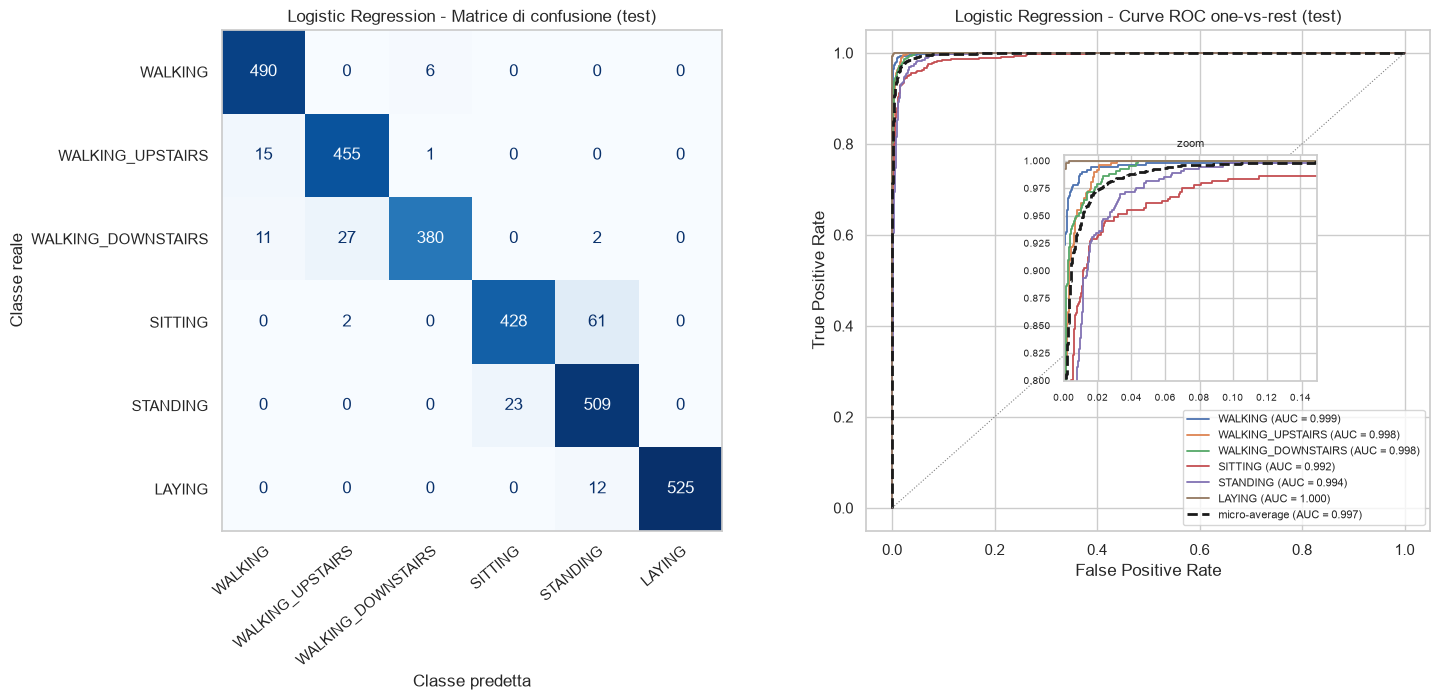

=== SVM (RBF) ===
                    precision    recall  f1-score   support

           WALKING      0.944     0.984     0.963       496
  WALKING_UPSTAIRS      0.914     0.970     0.941       471
WALKING_DOWNSTAIRS      0.987     0.874     0.927       420
           SITTING      0.935     0.880     0.907       491
          STANDING      0.898     0.944     0.920       532
            LAYING      1.000     1.000     1.000       537

          accuracy                          0.944      2947
         macro avg      0.946     0.942     0.943      2947
      weighted avg      0.946     0.944     0.944      2947

ROC AUC (OvR macro): 0.9970


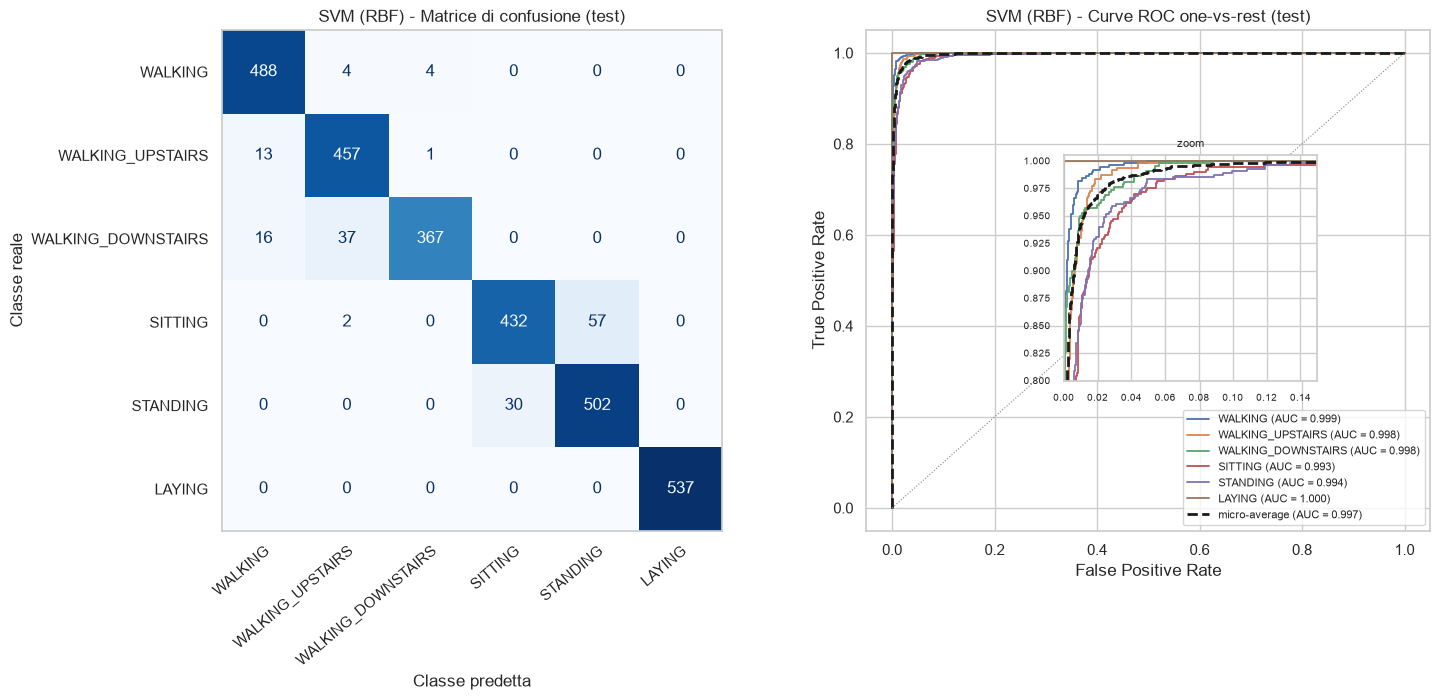

=== Random Forest ===
                    precision    recall  f1-score   support

           WALKING      0.881     0.970     0.923       496
  WALKING_UPSTAIRS      0.872     0.928     0.899       471
WALKING_DOWNSTAIRS      0.971     0.786     0.868       420
           SITTING      0.909     0.894     0.901       491
          STANDING      0.904     0.917     0.910       532
            LAYING      1.000     1.000     1.000       537

          accuracy                          0.920      2947
         macro avg      0.923     0.916     0.917      2947
      weighted avg      0.923     0.920     0.920      2947

ROC AUC (OvR macro): 0.9953


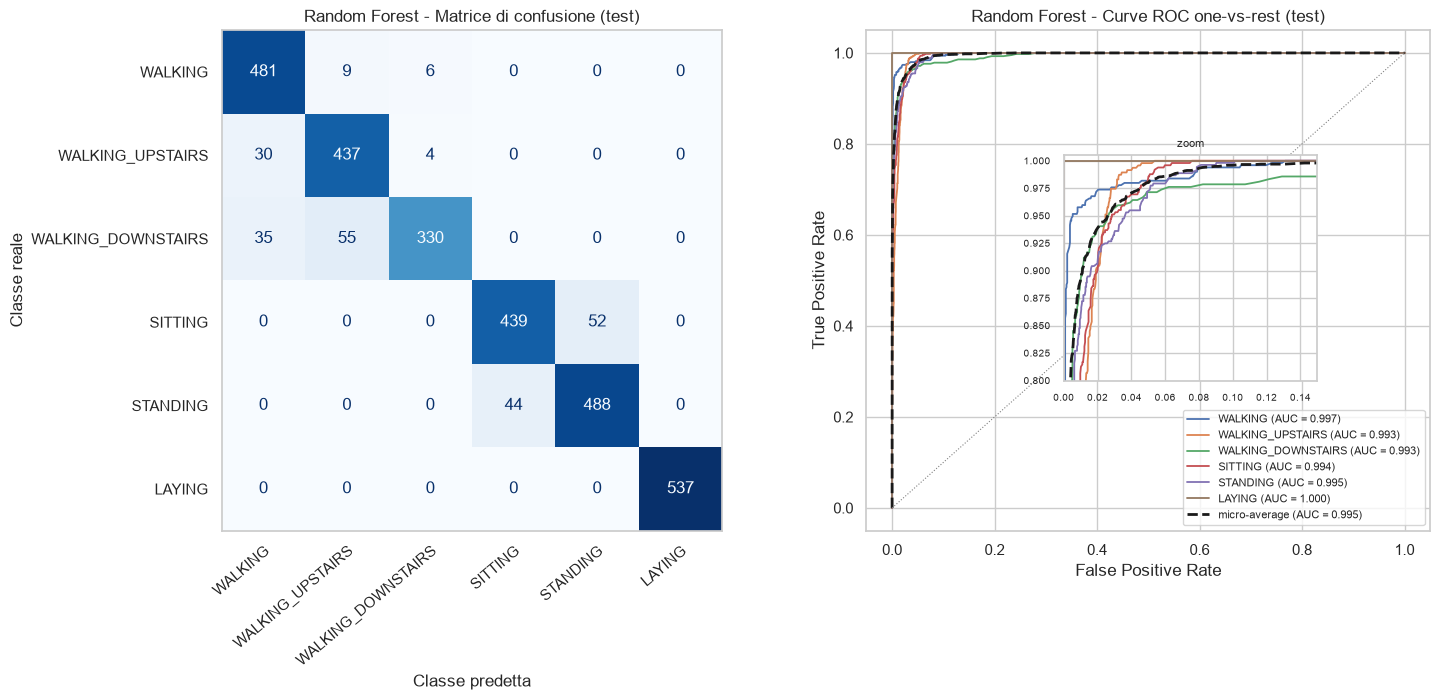

In [15]:
SIGLE = {"Logistic Regression": "logreg", "SVM (RBF)": "svm", "Random Forest": "random_forest"}
for i, (nome, modello) in enumerate(modelli.items()):
    y_pred = modello.predict(X_test_s)
    y_prob = modello.predict_proba(X_test_s)
    valuta(nome, y_test, y_pred, y_prob)
    grafici(nome, y_test, y_pred, y_prob, f"0{4 + i}_{SIGLE[nome]}_cm_roc")

## 6. Punto 5a — Approccio di deep learning

Implementiamo una rete neurale **MLP (Multi-Layer Perceptron)** in PyTorch, seguendo lo schema del classificatore multiclasse della lezione 31:
- input: le stesse 561 feature standardizzate usate dai modelli shallow;
- due strati nascosti (256 e 128 neuroni) con **BatchNorm**, attivazione **ReLU** e **Dropout** (0.3) come regolarizzazione;
- uscita: 6 logit, uno per classe; la softmax è incorporata nella **CrossEntropyLoss**;
- ottimizzatore **Adam** (learning rate 1e-3), batch da 64 esempi.

**Stessa suddivisione dei dati.** La rete usa esattamente gli stessi training, validation e test set dei modelli precedenti. Il validation set serve per l'**early stopping**: a ogni epoca si misura la loss di validazione e l'addestramento si ferma quando non migliora per 10 epoche consecutive, ripristinando i pesi migliori. Non viene usato `validation_split` o un'altra divisione interna.

In [16]:
class MLP(nn.Module):
    # MLP per classificazione in K classi; restituisce i logit grezzi
    def __init__(self, input_dim, n_classi, hidden_dims=(256, 128), dropout=0.3):
        super().__init__()
        strati = []
        dim_in = input_dim
        for dim_h in hidden_dims:
            strati += [nn.Linear(dim_in, dim_h), nn.BatchNorm1d(dim_h), nn.ReLU(), nn.Dropout(dropout)]
            dim_in = dim_h
        strati.append(nn.Linear(dim_in, n_classi))
        self.rete = nn.Sequential(*strati)

    def forward(self, x):
        return self.rete(x)


def tensori(X, y):
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)


Xtr_t, ytr_t = tensori(X_train_s, y_train)
Xva_t, yva_t = tensori(X_val_s, y_val)
Xte_t, yte_t = tensori(X_test_s, y_test)

torch.manual_seed(SEED)
loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=64, shuffle=True,
                    generator=torch.Generator().manual_seed(SEED))

rete = MLP(input_dim=X_train_s.shape[1], n_classi=len(CLASSI))
criterio = nn.CrossEntropyLoss()
ottimizzatore = torch.optim.Adam(rete.parameters(), lr=1e-3)
print(rete)
print("Parametri addestrabili:", sum(p.numel() for p in rete.parameters() if p.requires_grad))

MLP(
  (rete): Sequential(
    (0): Linear(in_features=561, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=6, bias=True)
  )
)
Parametri addestrabili: 178310


In [17]:
MAX_EPOCHE, PAZIENZA = 100, 10
storia = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
miglior_loss, epoche_senza_miglioramento, pesi_migliori = float("inf"), 0, None

for epoca in range(1, MAX_EPOCHE + 1):
    rete.train()
    for X_b, y_b in loader:
        ottimizzatore.zero_grad()
        perdita = criterio(rete(X_b), y_b)
        perdita.backward()
        ottimizzatore.step()

    # Valutazione a fine epoca su training e validation (modalità eval: niente dropout)
    rete.eval()
    with torch.no_grad():
        logit_tr, logit_va = rete(Xtr_t), rete(Xva_t)
        storia["train_loss"].append(criterio(logit_tr, ytr_t).item())
        storia["val_loss"].append(criterio(logit_va, yva_t).item())
        storia["train_acc"].append((logit_tr.argmax(1) == ytr_t).float().mean().item())
        storia["val_acc"].append((logit_va.argmax(1) == yva_t).float().mean().item())

    if storia["val_loss"][-1] < miglior_loss:
        miglior_loss, epoche_senza_miglioramento, epoca_migliore = storia["val_loss"][-1], 0, epoca
        pesi_migliori = {k: v.clone() for k, v in rete.state_dict().items()}
    else:
        epoche_senza_miglioramento += 1

    if epoca % 5 == 0 or epoche_senza_miglioramento == PAZIENZA:
        print(f"Epoca {epoca:3d} - loss train {storia['train_loss'][-1]:.4f} - loss val {storia['val_loss'][-1]:.4f}"
              f" - acc val {storia['val_acc'][-1]:.4f}")
    if epoche_senza_miglioramento == PAZIENZA:
        print(f"Early stopping: nessun miglioramento per {PAZIENZA} epoche")
        break

rete.load_state_dict(pesi_migliori)
print(f"Ripristinati i pesi dell'epoca {epoca_migliore} (loss di validazione {miglior_loss:.4f})")

Epoca   5 - loss train 0.0512 - loss val 0.0866 - acc val 0.9667


Epoca  10 - loss train 0.0452 - loss val 0.1483 - acc val 0.9545


Epoca  15 - loss train 0.0316 - loss val 0.1313 - acc val 0.9550


Epoca  20 - loss train 0.0208 - loss val 0.0668 - acc val 0.9767


Epoca  25 - loss train 0.0332 - loss val 0.0993 - acc val 0.9617


Epoca  30 - loss train 0.0194 - loss val 0.0955 - acc val 0.9706


Epoca  34 - loss train 0.0228 - loss val 0.1150 - acc val 0.9650
Early stopping: nessun miglioramento per 10 epoche
Ripristinati i pesi dell'epoca 24 (loss di validazione 0.0643)


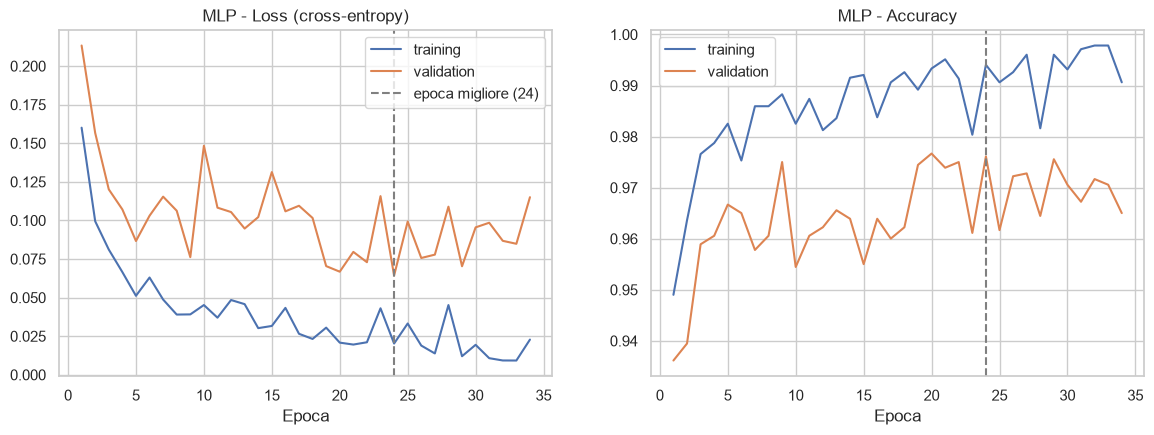

In [18]:
epoche = range(1, len(storia["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(epoche, storia["train_loss"], label="training")
ax[0].plot(epoche, storia["val_loss"], label="validation")
ax[0].axvline(epoca_migliore, ls="--", color="grey", label=f"epoca migliore ({epoca_migliore})")
ax[0].set_title("MLP - Loss (cross-entropy)")
ax[0].set_xlabel("Epoca")
ax[0].legend()
ax[1].plot(epoche, storia["train_acc"], label="training")
ax[1].plot(epoche, storia["val_acc"], label="validation")
ax[1].axvline(epoca_migliore, ls="--", color="grey")
ax[1].set_title("MLP - Accuracy")
ax[1].set_xlabel("Epoca")
ax[1].legend()
salva("07_mlp_curve_addestramento")
plt.show()

=== MLP (PyTorch) ===
                    precision    recall  f1-score   support

           WALKING      0.987     0.917     0.951       496
  WALKING_UPSTAIRS      0.966     0.964     0.965       471
WALKING_DOWNSTAIRS      0.893     0.971     0.930       420
           SITTING      0.972     0.851     0.908       491
          STANDING      0.877     0.977     0.924       532
            LAYING      1.000     0.998     0.999       537

          accuracy                          0.947      2947
         macro avg      0.949     0.947     0.946      2947
      weighted avg      0.950     0.947     0.947      2947

ROC AUC (OvR macro): 0.9962


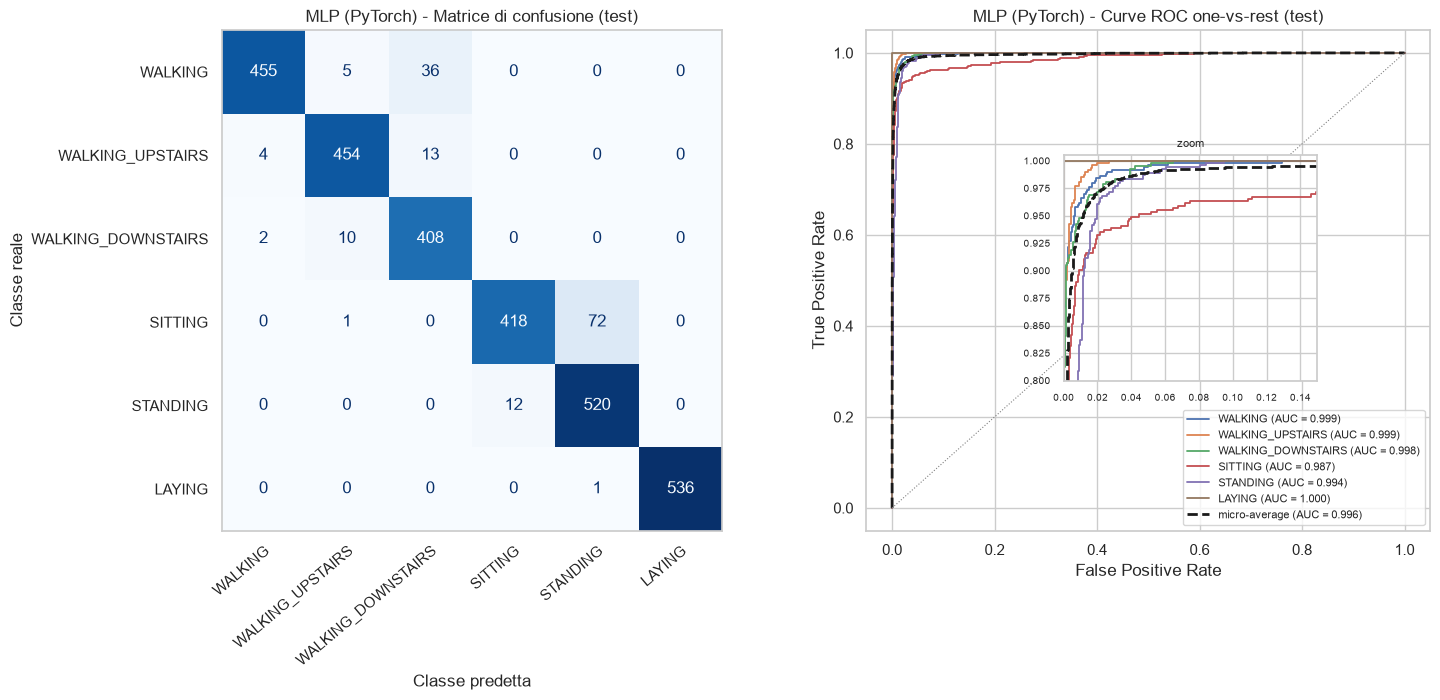

In [19]:
rete.eval()
with torch.no_grad():
    prob_mlp = torch.softmax(rete(Xte_t), dim=1).numpy()
pred_mlp = prob_mlp.argmax(axis=1)

valuta("MLP (PyTorch)", y_test, pred_mlp, prob_mlp)
grafici("MLP (PyTorch)", y_test, pred_mlp, prob_mlp, "08_mlp_cm_roc")

## 7. Confronto finale

In [20]:
confronto = pd.DataFrame(risultati).T
confronto.round(4)

,Accuracy,Precision (macro),Recall (macro),F1 (macro),ROC AUC (OvR macro)
Logistic Regression,0.9457,0.9487,0.9441,0.9454,0.9970
SVM (RBF),0.9444,0.9463,0.9419,0.9431,0.9970
Random Forest,0.9203,0.9227,0.9158,0.9171,0.9953
MLP (PyTorch),0.9471,0.9491,0.9466,0.9462,0.9962


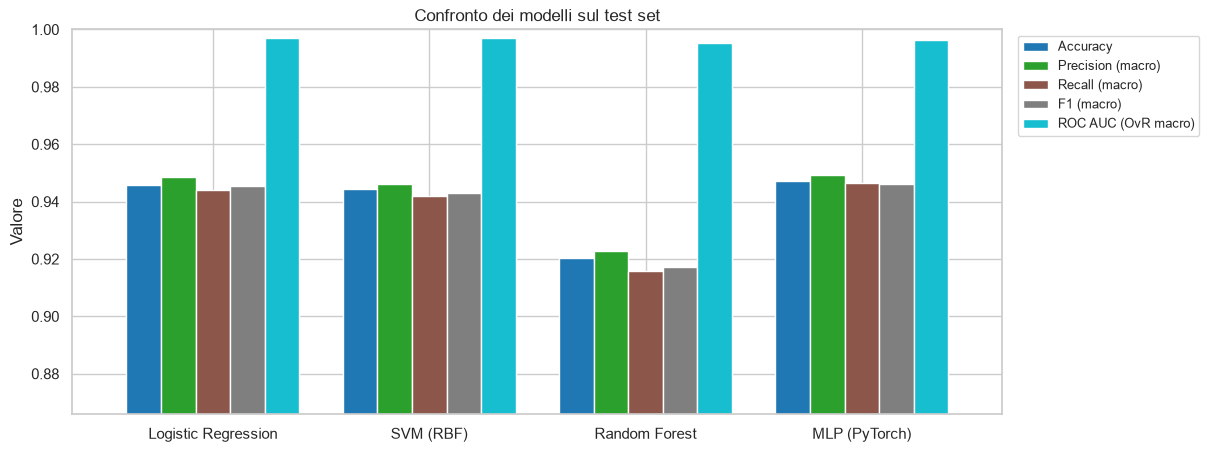

In [21]:
ax = confronto.plot(kind="bar", figsize=(12, 5), width=0.8, colormap="tab10")
ax.set_ylim(max(0.0, confronto.values.min() - 0.05), 1.0)
ax.set_title("Confronto dei modelli sul test set")
ax.set_ylabel("Valore")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)
plt.xticks(rotation=0)
salva("09_confronto_modelli")
plt.show()

## 8. Conclusioni

**Risultati.** Tutti i modelli superano il 92% di accuracy su 9 volontari mai visti in addestramento, con ROC AUC macro sopra 0,99.

| Modello | Accuracy | F1 macro | Commento |
|---|---|---|---|
| MLP (PyTorch) | ~94,7% | ~0,946 | il migliore di pochissimo |
| Logistic Regression | ~94,6% | ~0,945 | il migliore tra i modelli shallow, con una regolarizzazione piuttosto forte (C = 0,1) |
| SVM (RBF) | ~94,4% | ~0,943 | praticamente allineata alla Logistic Regression |
| Random Forest | ~92,0% | ~0,917 | il più debole, soprattutto su *WALKING_DOWNSTAIRS* (recall ~0,79) |

**Errori ricorrenti.** Le matrici di confusione mostrano gli stessi due punti deboli per tutti i modelli:
1. **Seduto e in piedi** si confondono in entrambe le direzioni, soprattutto *SITTING* classificato come *STANDING*. Con il telefono in vita le due posture producono segnali quasi identici: il corpo è fermo e la gravità agisce nella stessa direzione. È la stessa sovrapposizione già vista nella PCA.
2. **Le tre camminate** si confondono tra loro, ma in modo diverso a seconda del modello. I modelli shallow tendono a scambiare *scendere le scale* per *salire le scale* o *camminare in piano* (recall di *WALKING_DOWNSTAIRS* tra 0,79 e 0,91). La MLP fa l'errore opposto: riconosce bene la discesa (recall 0,97) ma classifica come discesa una parte delle camminate in piano (recall di *WALKING* 0,92). Il totale degli errori è simile, ma la loro distribuzione no: è un'informazione che la sola accuracy non mostra.

*LAYING* invece è riconosciuta quasi sempre correttamente: da sdraiati la gravità cambia asse rispetto al telefono e il segnale diventa inconfondibile.

**Deep learning e modelli shallow.** La rete MLP ottiene il risultato migliore, ma il vantaggio sulla Logistic Regression è di circa 0,1 punti percentuali, cioè **4 finestre su 2.947**: una differenza che non si può considerare significativa. Le 561 feature sono già state progettate a mano da esperti di elaborazione dei segnali, quindi contengono già l'informazione utile: un modello lineare basta a sfruttarla quasi del tutto. Il vantaggio del deep learning, che apprende da solo le rappresentazioni (lezione 4), emergerebbe meglio usando i **segnali inerziali grezzi** inclusi nel dataset (cartella `Inertial Signals`) con reti convoluzionali o ricorrenti. È un possibile sviluppo futuro.

**Overfitting.** Le curve di addestramento della MLP mostrano un'accuracy di training vicina al 99% contro circa il 97% in validazione, e una loss di validazione che oscilla. Dropout e BatchNorm contengono l'overfitting, e l'**early stopping** sul validation set ferma l'addestramento riportando i pesi dell'epoca migliore. Le oscillazioni dipendono anche dal validation set piccolo (5 volontari).

**Limiti.**
- I risultati si riferiscono a una sola suddivisione e a un solo seed. Una stima più robusta richiederebbe una cross-validation per volontario (ad esempio `GroupKFold`), più costosa ma possibile.
- Il calo di prestazioni dal validation al test (per la Logistic Regression la F1 passa da 0,957 a 0,945) conferma che **generalizzare a persone nuove** è la vera difficoltà del problema. È il motivo per cui la divisione per volontario, e non per riga, era necessaria.